# Spin-photon correlation

Build a 2 x 2 correlation matrix between the photon time bin (early/late optical pi pulse) and the spin projection (bright SSR configured for e1/e2). The analysis uses the saved raw traces.

In [ ]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

DATA_DIR = Path(r"F:\Data\NuclearOps\Qinu\spin_photon_corr_MW\20260923-h20m26s58_spin_photon_corr_MW")

# Inclusive saved sweep numbers (the data normally starts at sweep 0).
# Example: (1, 20) keeps sweeps 1 through 20; None keeps all sweeps.
SWEEP_RANGE = (1, 3)

# Thresholds from spin_photon_corr_MW.py. Comparisons remain strict.
INITIAL_CSR_MAX = 1       # accept initial check < 1
FINAL_CSR_MIN = 6         # accept final charge check > 3
SSR_BRIGHT_THRESHOLD = 2  # bright SSR when count > 2
PHOTON_THRESHOLD = 0      # photon detected when count > 0

# True keeps only one click in total across the early and late windows.
# False accepts any detection in one window, provided the other is dark.
REQUIRE_EXACTLY_ONE_CLICK = True

In [9]:
with (DATA_DIR / "measurement.json").open() as f:
    metadata = json.load(f)
with (DATA_DIR / "results.json").open() as f:
    results_payload = json.load(f)

assert metadata["format"] == "nuclearops-efficient-traces"
results = pd.DataFrame(results_payload["data"])

# Filter before loading any traces so every plot/statistic uses this selection.
if SWEEP_RANGE is not None:
    first_sweep, last_sweep = SWEEP_RANGE
    if first_sweep > last_sweep:
        raise ValueError("SWEEP_RANGE must have first_sweep <= last_sweep")
    results = results.loc[
        results["sweeps"].between(first_sweep, last_sweep, inclusive="both")
    ].copy().reset_index(drop=True)
if results.empty:
    raise ValueError(f"No acquisitions found for SWEEP_RANGE={SWEEP_RANGE}")
print("Using sweeps:", sorted(results["sweeps"].unique().tolist()))
display(results[["sweeps", "init_state", "SSR_state", "trace"]])

Using sweeps: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


,sweeps,init_state,SSR_state,trace
0,1,e1,e1,traces/9d8d50a56c0d4365a3528451ab15a1fa.npy
1,1,e1,e2,traces/0f2603187e1741ff9286f2fb24f25c58.npy
2,2,e1,e1,traces/87d0c90f833c47c8b167e0f53026e531.npy
3,2,e1,e2,traces/77d28d34996d48d0af494d427b7bc69c.npy
4,3,e1,e1,traces/ae7782e466944637a4b3ee82de042116.npy
5,3,e1,e2,traces/9dadd288728948aebc93667b9fed3b67.npy
6,4,e1,e1,traces/b2cc88a1c2794601a525ac7f9f7de3dd.npy
7,4,e1,e2,traces/7be1f59e0820474b9156200beed4e096.npy
8,5,e1,e1,traces/d59d37776915459084ce71e6ceef7d69.npy
9,5,e1,e2,traces/314dce16f2e645b599bdade241aa34ff.npy


The five raw values in each repetition follow the measurement script: initial charge check, early photon, late photon, SSR, final charge check. A bright SSR event measures whichever state is named by `SSR_state` for that trace.

In [10]:
WINDOWS_PER_SHOT = 5
records = []
diagnostics = []
ssr_counts_by_state = {"e1": [], "e2": []}
csr_counts_all = []

for row in results.itertuples(index=False):
    trace_path = DATA_DIR / row.trace
    raw = np.load(trace_path, mmap_mode="r", allow_pickle=False)
    if raw.size % WINDOWS_PER_SHOT:
        raise ValueError(f"{trace_path.name}: trace length is not divisible by {WINDOWS_PER_SHOT}")
    shots = np.asarray(raw).reshape(-1, WINDOWS_PER_SHOT)
    initial_csr, early_counts, late_counts, ssr_counts, final_csr = shots.T

    charge_valid = (initial_csr < INITIAL_CSR_MAX) & (final_csr > FINAL_CSR_MIN)
    ssr_bright = ssr_counts > SSR_BRIGHT_THRESHOLD
    ssr_counts_by_state[row.SSR_state].append(np.asarray(ssr_counts[charge_valid]))
    csr_counts_all.append(np.asarray(final_csr))

    if REQUIRE_EXACTLY_ONE_CLICK:
        early = (early_counts == 1) & (late_counts == 0)
        late = (early_counts == 0) & (late_counts == 1)
    else:
        early_detected = early_counts > PHOTON_THRESHOLD
        late_detected = late_counts > PHOTON_THRESHOLD
        early = early_detected & ~late_detected
        late = ~early_detected & late_detected

    for time_bin, photon_mask in (("early", early), ("late", late)):
        records.append({
            "spin_state": row.SSR_state,
            "time_bin": time_bin,
            "valid_shots": int(charge_valid.sum()),
            "photon_shots": int((charge_valid & photon_mask).sum()),
            "bright_coincidences": int((charge_valid & photon_mask & ssr_bright).sum()),
        })

    diagnostics.append({
        "sweep": row.sweeps,
        "SSR_state": row.SSR_state,
        "shots": len(shots),
        "charge_valid": int(charge_valid.sum()),
        "early_single": int((charge_valid & early).sum()),
        "late_single": int((charge_valid & late).sum()),
        "SSR_bright": int((charge_valid & ssr_bright).sum()),
    })

diagnostics = pd.DataFrame(diagnostics)
display(diagnostics)

,sweep,SSR_state,shots,charge_valid,early_single,late_single,SSR_bright
0,1,e1,100000,83635,33,9,22611
1,1,e2,100000,80673,20,14,24446
2,2,e1,100000,75767,21,18,20582
3,2,e2,100000,79015,20,19,24115
4,3,e1,100000,73655,19,11,19870
5,3,e2,100000,73041,18,14,22058
6,4,e1,100000,65802,11,10,17645
7,4,e2,100000,69608,20,12,21080
8,5,e1,100000,62945,15,19,17016
9,5,e2,100000,73627,13,15,22291


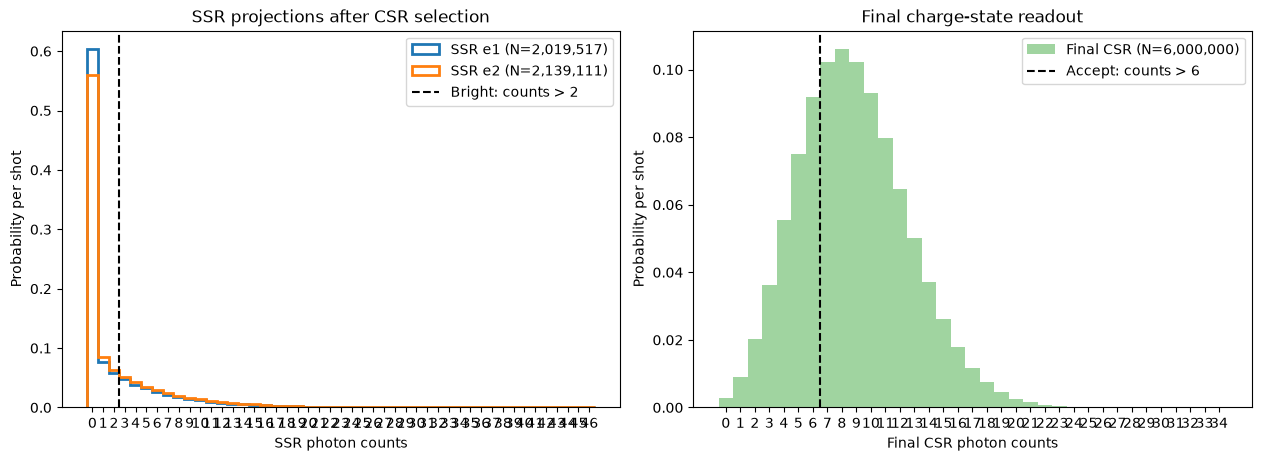

,shots,mean_counts,bright_fraction
e1,2019517.0,2.108651,0.260027
e2,2139111.0,2.351119,0.291657


In [11]:
# Compare the two bright-state SSR projections before constructing the correlation matrix.
ssr_distributions = {
    state: np.concatenate(parts) if parts else np.array([], dtype=int)
    for state, parts in ssr_counts_by_state.items()
}
csr_distribution = np.concatenate(csr_counts_all) if csr_counts_all else np.array([], dtype=int)
max_ssr_count = max((int(values.max()) for values in ssr_distributions.values() if values.size), default=0)
ssr_bins = np.arange(-0.5, max_ssr_count + 1.5, 1)
max_csr_count = int(csr_distribution.max()) if csr_distribution.size else 0
csr_bins = np.arange(-0.5, max_csr_count + 1.5, 1)

fig, (ax_ssr, ax_csr) = plt.subplots(1, 2, figsize=(12.5, 4.5), constrained_layout=True)
for state, color in (("e1", "tab:blue"), ("e2", "tab:orange")):
    values = ssr_distributions[state]
    ax_ssr.hist(values, bins=ssr_bins, density=True, histtype="step", linewidth=2,
            label=f"SSR {state} (N={values.size:,})", color=color)

ax_ssr.axvline(SSR_BRIGHT_THRESHOLD + 0.5, color="black", linestyle="--", linewidth=1.5,
           label=f"Bright: counts > {SSR_BRIGHT_THRESHOLD}")
ax_ssr.set_xlabel("SSR photon counts")
ax_ssr.set_ylabel("Probability per shot")
ax_ssr.set_title("SSR projections after CSR selection")
ax_ssr.set_xticks(np.arange(0, max_ssr_count + 1))
ax_ssr.legend()

ax_csr.hist(csr_distribution, bins=csr_bins, density=True, histtype="stepfilled",
            alpha=0.45, color="tab:green", label=f"Final CSR (N={csr_distribution.size:,})")
ax_csr.axvline(FINAL_CSR_MIN + 0.5, color="black", linestyle="--", linewidth=1.5,
               label=f"Accept: counts > {FINAL_CSR_MIN}")
ax_csr.set_xlabel("Final CSR photon counts")
ax_csr.set_ylabel("Probability per shot")
ax_csr.set_title("Final charge-state readout")
ax_csr.set_xticks(np.arange(0, max_csr_count + 1))
ax_csr.legend()
plt.show()

pd.DataFrame({
    state: {
        "shots": values.size,
        "mean_counts": values.mean() if values.size else np.nan,
        "bright_fraction": (values > SSR_BRIGHT_THRESHOLD).mean() if values.size else np.nan,
    }
    for state, values in ssr_distributions.items()
}).T

In [12]:
summary = (pd.DataFrame(records)
           .groupby(["spin_state", "time_bin"], as_index=False)
           .sum(numeric_only=True))
summary["bright_coincidence_rate"] = (
    summary["bright_coincidences"] / summary["valid_shots"]
)
display(summary)

state_order = ["e1", "e2"]
bin_order = ["early", "late"]
rates = (summary.pivot(index="spin_state", columns="time_bin",
                       values="bright_coincidence_rate")
         .reindex(index=state_order, columns=bin_order))
counts = (summary.pivot(index="spin_state", columns="time_bin",
                        values="bright_coincidences")
          .reindex(index=state_order, columns=bin_order))

# The e1 and e2 projections were acquired in separate runs. Normalize each
# photon-bin column after correcting each cell by its number of valid shots.
correlation = rates.div(rates.sum(axis=0), axis=1)
correlation

,spin_state,time_bin,valid_shots,photon_shots,bright_coincidences,bright_coincidence_rate
0,e1,early,2019517,715,109,0.000054
1,e1,late,2019517,628,264,0.000131
2,e2,early,2139111,778,301,0.000141
3,e2,late,2139111,677,101,0.000047


time_bin,early,late
spin_state,,
e1,0.277233,0.734653
e2,0.722767,0.265347


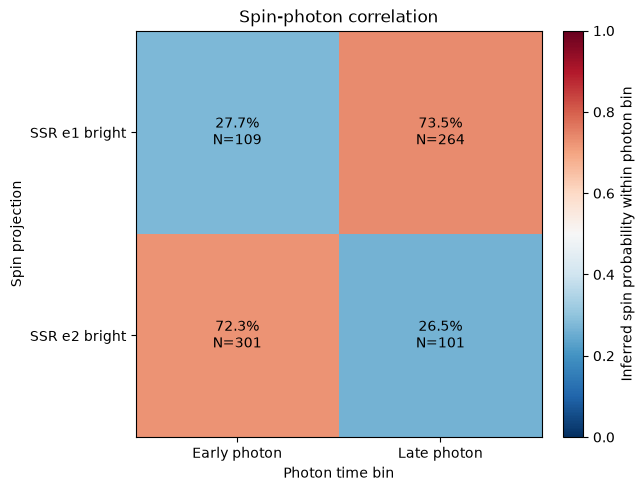

In [13]:
fig, ax = plt.subplots(figsize=(6.2, 4.8), constrained_layout=True)
image = ax.imshow(correlation.to_numpy(), vmin=0, vmax=1, cmap="RdBu_r", aspect="equal")
ax.set_xticks(range(2), ["Early photon", "Late photon"])
ax.set_yticks(range(2), ["SSR e1 bright", "SSR e2 bright"])
ax.set_xlabel("Photon time bin")
ax.set_ylabel("Spin projection")
ax.set_title("Spin-photon correlation")

for i, state in enumerate(state_order):
    for j, time_bin in enumerate(bin_order):
        value = correlation.loc[state, time_bin]
        count = int(counts.loc[state, time_bin])
        color = "white" if value < 0.25 or value > 0.75 else "black"
        ax.text(j, i, f"{value:.1%}\nN={count}", ha="center", va="center", color=color)

cbar = fig.colorbar(image, ax=ax, ticks=np.linspace(0, 1, 6))
cbar.set_label("Inferred spin probability within photon bin")
plt.show()

In [ ]:
# Optional scalar contrast: +1 means early->e2 and late->e1; -1 is reversed.
contrast = 0.5 * (
    correlation.loc["e2", "early"]
    + correlation.loc["e1", "late"]
    - correlation.loc["e1", "early"]
    - correlation.loc["e2", "late"]
)
print(f"Early-e2 / late-e1 correlation contrast: {contrast:.4f}")